In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp


In [2]:
#Conversions
boundary_  = lambda p:p.view(np.uint32) >> 16    
flag_      = lambda p:p.view(np.uint32) & 0xffff

identity_ = lambda p:p.view(np.uint32)[3,1]   
primIdx_   = lambda p:identity_(p) >> 16  
instanceId_  = lambda p:identity_(p) & 0xffff  

idx_      = lambda p:p.view(np.uint32)[3,2] & 0x7fffffff
orient_   = lambda p:p.view(np.uint32)[3,2] >> 31

flagmask_ = lambda p:p.view(np.uint32)


In [3]:
## Root 

In [4]:
import uproot

In [5]:
myfile=uproot.open("/home/argon/Projects/Ilker/gxsim/CRAB/macros/Mesh2mm_30RandomEvents.root")

In [6]:

Opticks=myfile["ntuple/Opticks_PMT_Hits"]
OpticksCamera=myfile["ntuple/Opticks_Camera_Hits"]

EL=myfile["ntuple/EL"]
PMT=myfile["ntuple/PMT"]
Camera=myfile["ntuple/Camera"]

In [7]:
PMTZ=PMT["Z"].array()
CameraZ=Camera["Z"].array()
OpticksZ=Opticks["z"].array()
OpticksCameraZ=OpticksCamera["z"].array()

#print(f"Camera Event --> {Event}")
print(f"PMT array --> {PMTZ}")
print(f"Camera array --> {CameraZ}")
print(f"Opticks PMT array --> {OpticksZ}")
print(f"Opticks Camera array --> {OpticksCameraZ}")
Elx=EL["X"].array()
print(f"ELX --> {Elx}")

PMT array --> [-243, -243, -243, -243, -243, -243, ..., -243, -243, -243, -243, -243, -243]
Camera array --> [228, 228, 228, 228, 228, 229, 228, 228, ..., 229, 229, 228, 228, 229, 228, 286]
Opticks PMT array --> [-247, -246, -246, -246, -246, -245, ..., -245, -245, -247, -245, -245, -247]
Opticks Camera array --> [306, 306, 306, 306, 306, 306, 306, 306, ..., 306, 306, 306, 306, 306, 306, 306]
ELX --> [-1.83, -1.7, -1.74, -2.21, -2.07, -2.03, ..., 0.799, 0.23, 0.655, 1.18, 0.441]


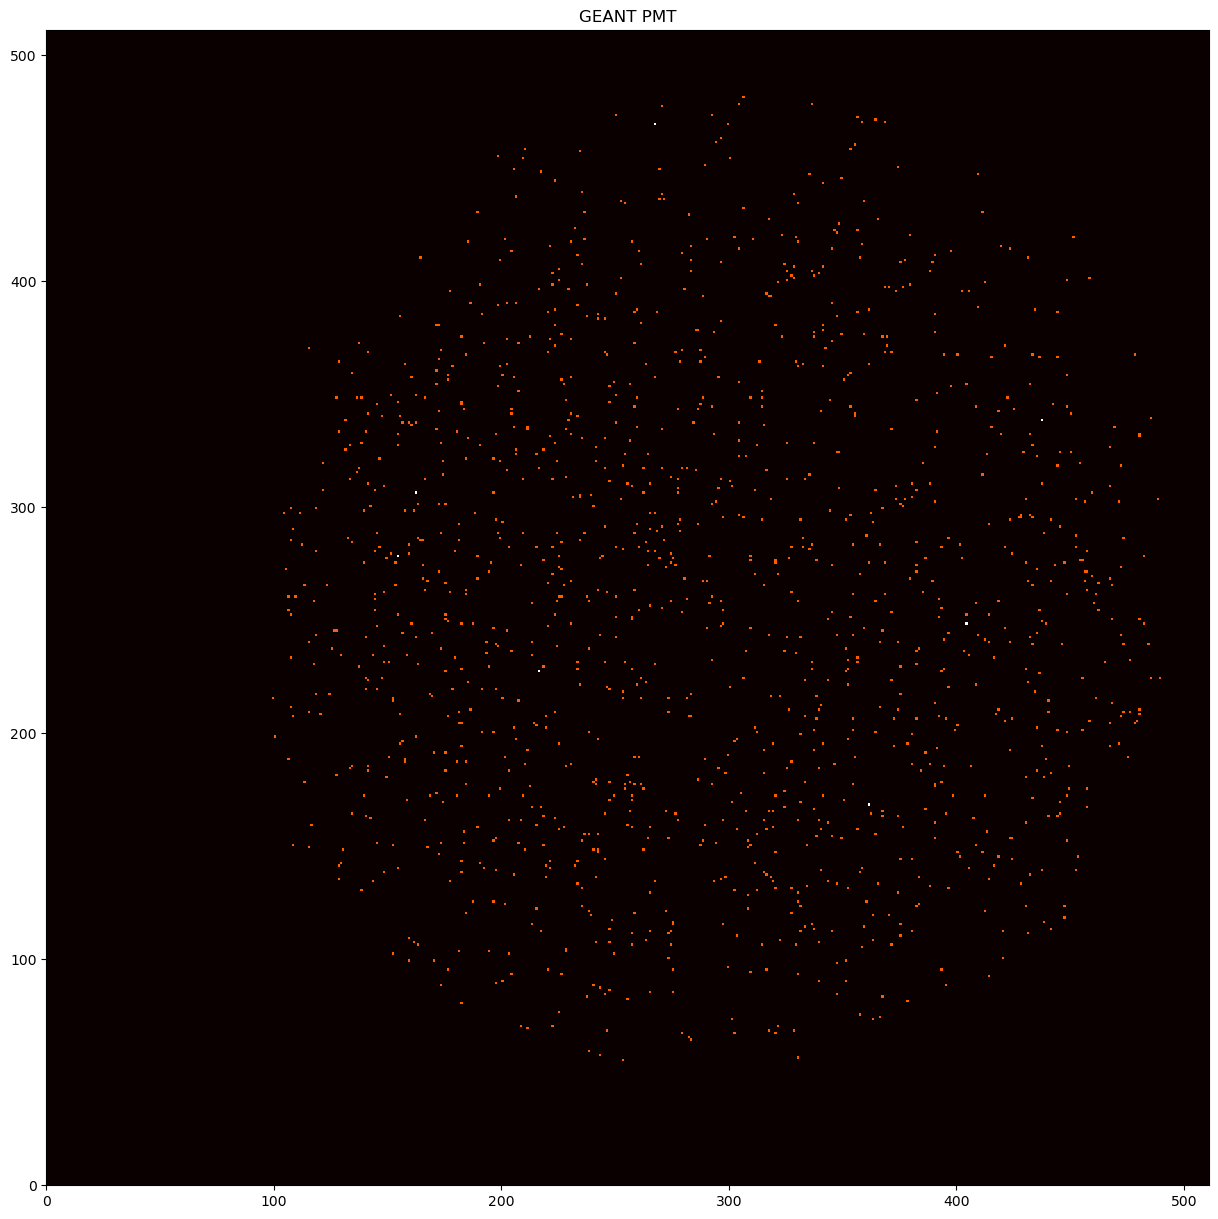

In [8]:
plt.figure(figsize=(15,15))
plt.title("GEANT PMT")
X=PMT["X"]
Y=PMT["Y"]
theta=-np.pi/8
costet=np.cos(theta)
sintet=np.sin(theta)
pixelsize=0.016

XRotated=(X*costet-sintet*Y)
YRotated=-(X*sintet+costet*Y)

XRotated=((XRotated)/(pixelsize*3))+260+30
YRotated=((YRotated)/(pixelsize*3)+230+40)

XRotated=np.array(XRotated)
YRotated=np.array(YRotated)
h2=plt.hist2d(XRotated,YRotated,bins=[np.arange(0,512,1),np.arange(0,512,1)],cmap="hot")

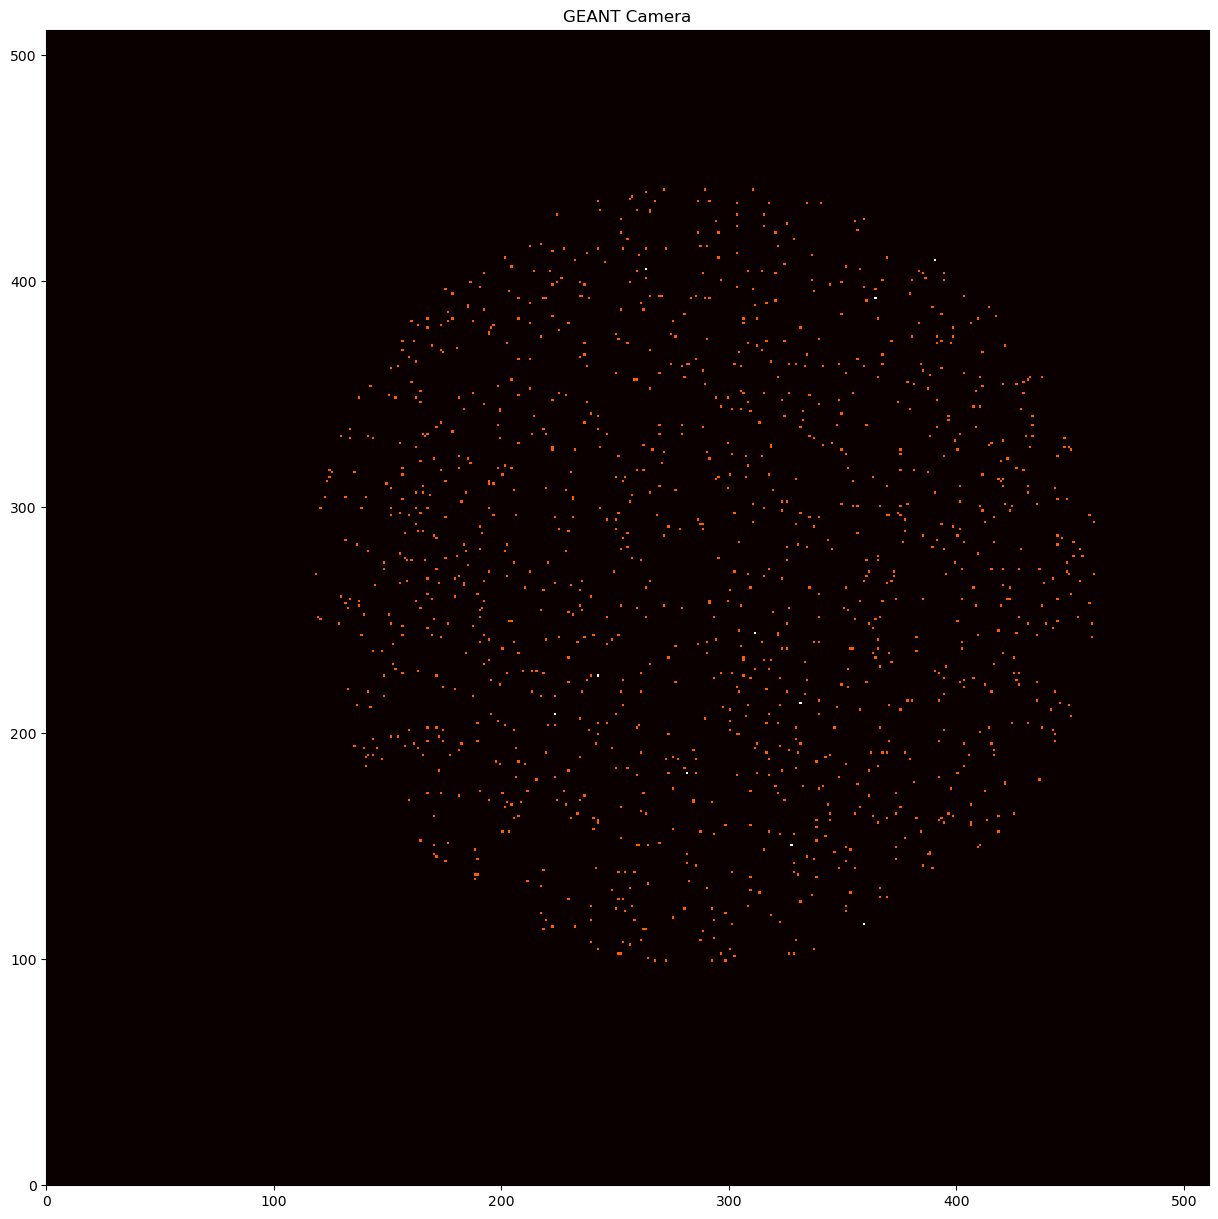

In [9]:
plt.figure(figsize=(15,15))
plt.title("GEANT Camera")
X=Camera["X"]
Y=Camera["Y"]
theta=-np.pi/8
costet=np.cos(theta)
sintet=np.sin(theta)
pixelsize=0.016

XRotated=(X*costet-sintet*Y)
YRotated=-(X*sintet+costet*Y)

XRotated=((XRotated)/(pixelsize*3))+260+30
YRotated=((YRotated)/(pixelsize*3)+230+40)

XRotated=np.array(XRotated)
YRotated=np.array(YRotated)
h2=plt.hist2d(XRotated,YRotated,bins=[np.arange(0,512,1),np.arange(0,512,1)],cmap="hot")

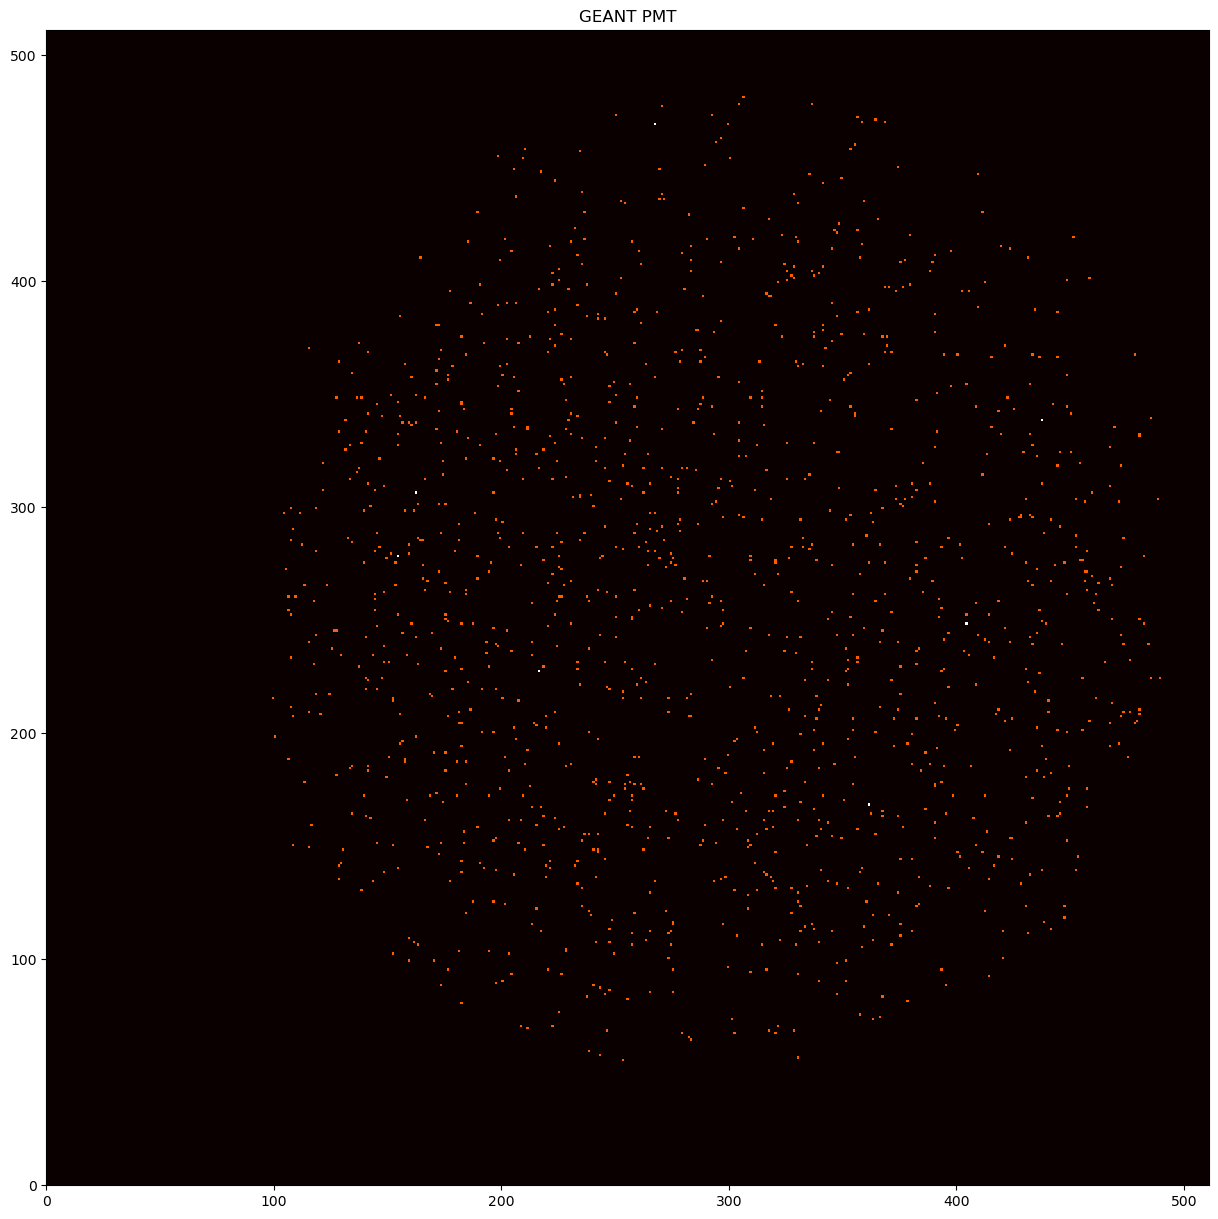

In [10]:
plt.figure(figsize=(15,15))
plt.title("GEANT PMT")
X=PMT["X"]
Y=PMT["Y"]
theta=-np.pi/8
costet=np.cos(theta)
sintet=np.sin(theta)
pixelsize=0.016

XRotated=(X*costet-sintet*Y)
YRotated=-(X*sintet+costet*Y)

XRotated=((XRotated)/(pixelsize*3))+260+30
YRotated=((YRotated)/(pixelsize*3)+230+40)

XRotated=np.array(XRotated)
YRotated=np.array(YRotated)
h2=plt.hist2d(XRotated,YRotated,bins=[np.arange(0,512,1),np.arange(0,512,1)],cmap="hot")


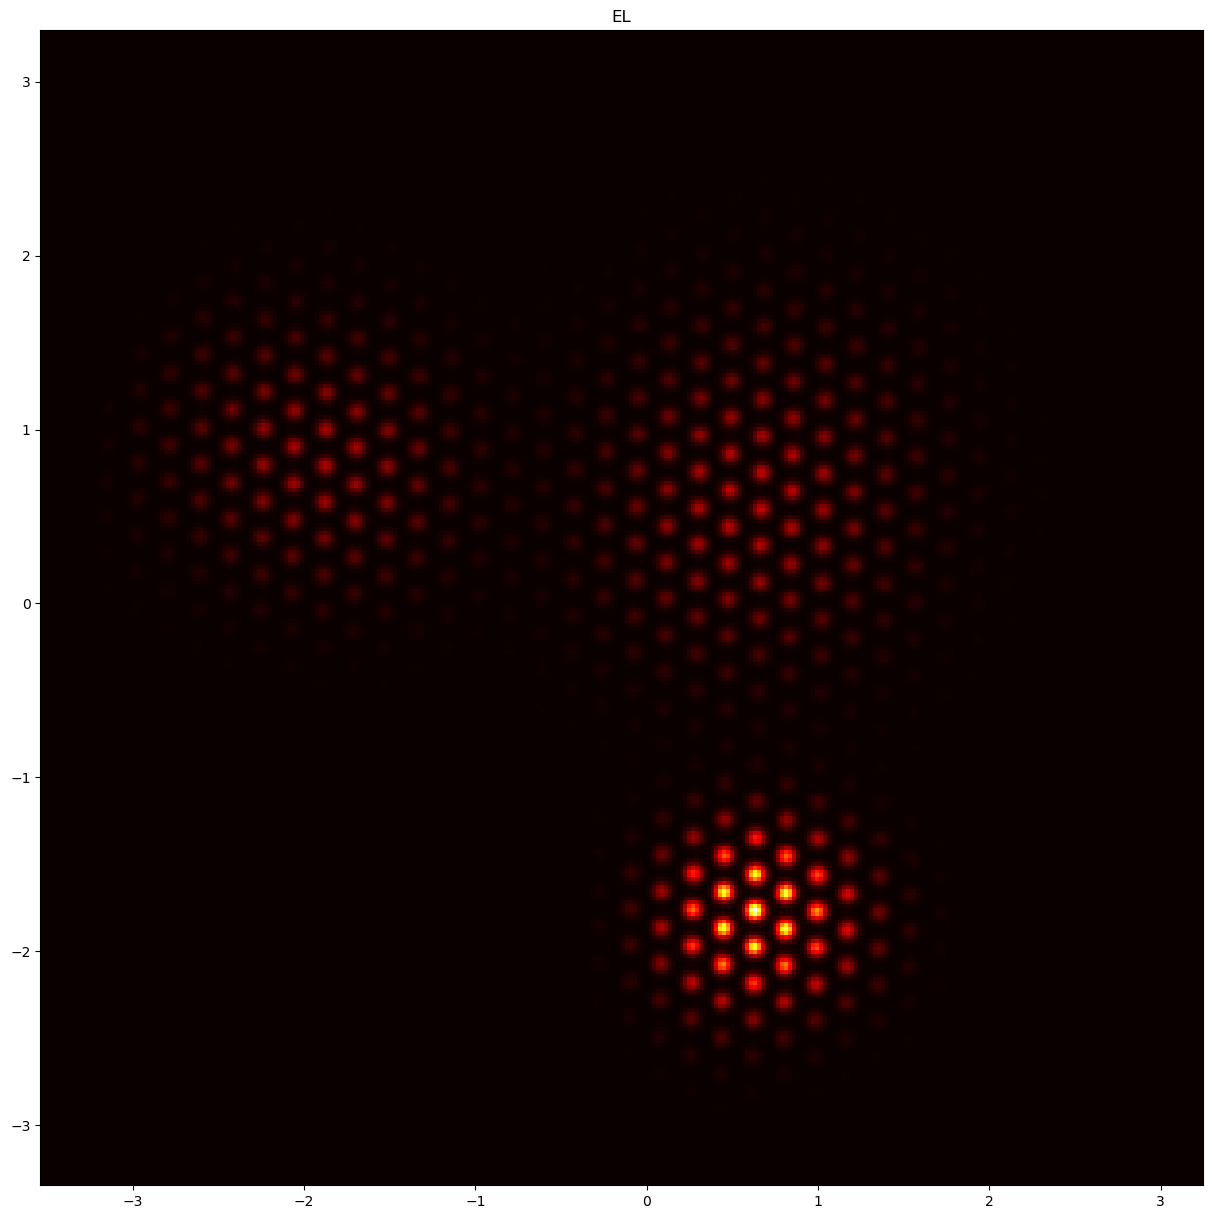

In [11]:
plt.figure(figsize=(15,15))
plt.title("EL")
_=plt.hist2d(EL["X"],EL["Y"],bins=300,cmap="hot")

In [12]:
Event=0
EventMask=np.array(OpticksCamera["Event"].array())==Event
OpticksCameraX=np.array(OpticksCamera["x"].array())[EventMask]
OpticksCameraY=np.array(OpticksCamera["y"].array())[EventMask]
EventMask=np.array(Opticks["Event"].array())==Event
OpticksPMTX=np.array(Opticks["x"].array())[EventMask]
OpticksPMTY=np.array(Opticks["y"].array())[EventMask]

print(len(OpticksPMTX))
OpticksCameraX=OpticksCamera["x"]
OpticksCameraY=OpticksCamera["y"]

120804


binss=np.linspace(0,500,50)
_=plt.hist(OpticksCamera["Event"].array(),bins=binss)

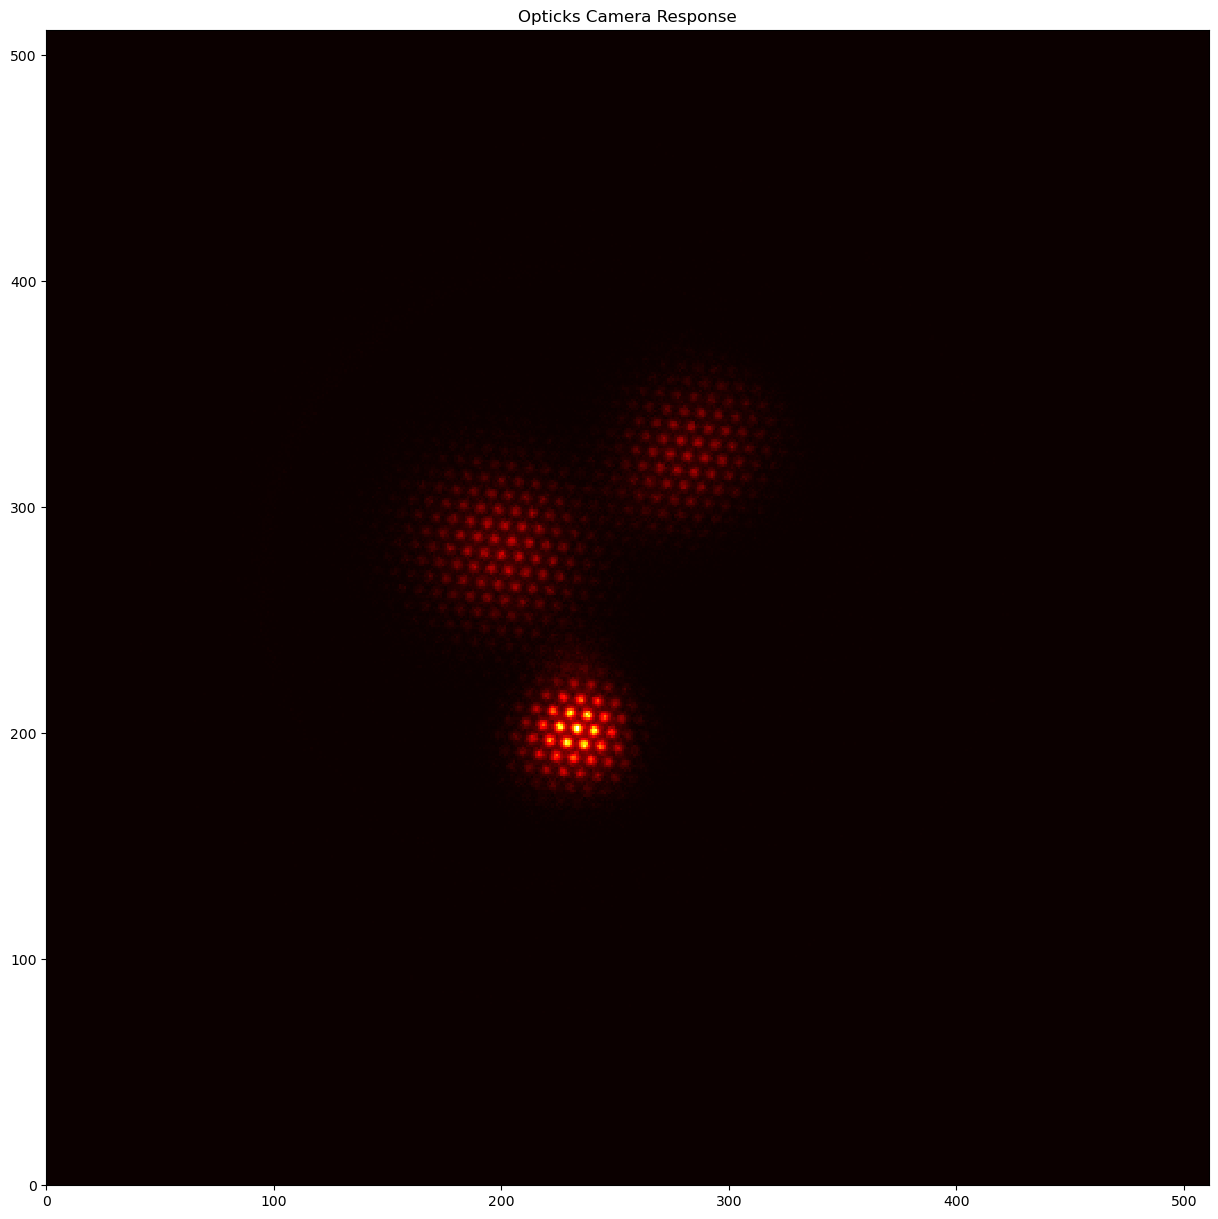

In [13]:

plt.figure(figsize=(15,15))
_=plt.hist2d(OpticksCameraX,OpticksCameraY,bins=500)
X=OpticksCameraX
Y=OpticksCameraY
theta=-np.pi/8
costet=np.cos(theta)
sintet=np.sin(theta)
pixelsize=0.016

XRotated=(X*costet-sintet*Y)
YRotated=-(X*sintet+costet*Y)

XRotated=((XRotated)/(pixelsize*4))+200+30
YRotated=((YRotated)/(pixelsize*4)+230+40)

XRotated=np.array(XRotated)
YRotated=np.array(YRotated)
plt.title("Opticks Camera Response")
h2=plt.hist2d(XRotated,YRotated,bins=[np.arange(0,512,1),np.arange(0,512,1)],cmap="hot")

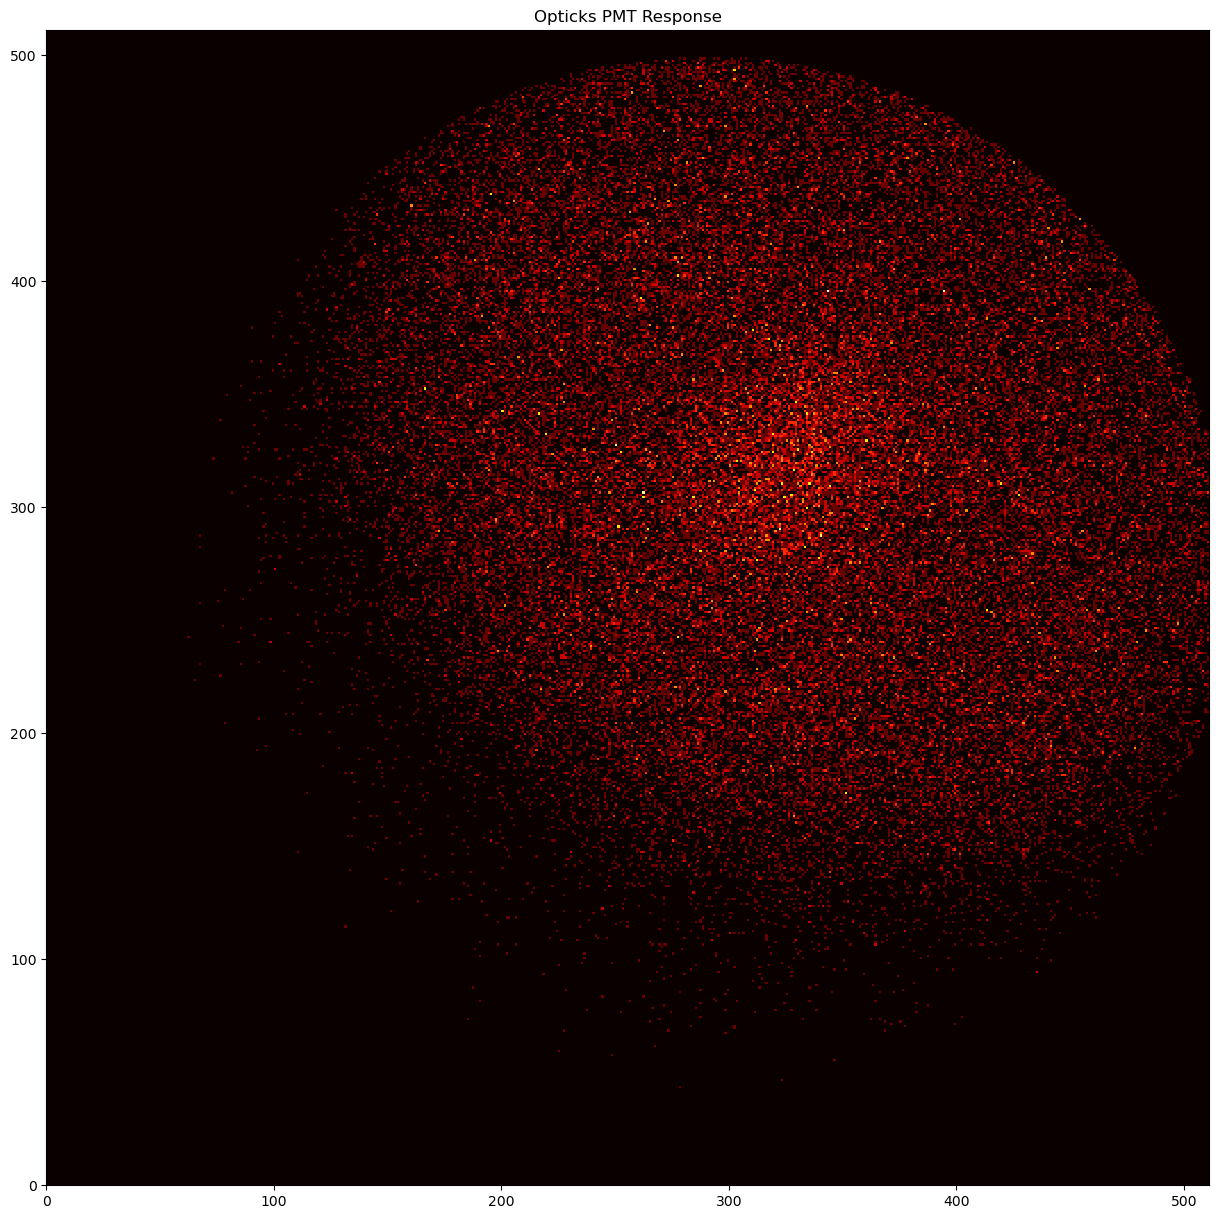

In [14]:
plt.figure(figsize=(15,15))
_=plt.hist2d(Opticks["x"],Opticks["y"],bins=500)
X=OpticksPMTX
Y=OpticksPMTY
theta=-np.pi/8
costet=np.cos(theta)
sintet=np.sin(theta)
pixelsize=0.016

XRotated=(X*costet-sintet*Y)
YRotated=-(X*sintet+costet*Y)

XRotated=((XRotated)/(pixelsize*3))+260+30
YRotated=((YRotated)/(pixelsize*3)+230+40)

XRotated=np.array(XRotated)
YRotated=np.array(YRotated)
plt.title("Opticks PMT Response")
h2=plt.hist2d(XRotated,YRotated,bins=[np.arange(0,512,1),np.arange(0,512,1)],cmap="hot")

In [15]:
### Opticks Nexus Analysis

import h5py

In [16]:
f=h5py.File("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4OpticksTest_No_Reflection.h5","r")

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4OpticksTest_No_Reflection.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [174]:
f["MC"]

<HDF5 group "/MC" (8 members)>

In [175]:
Event=np.array(f["MC"]["Opticks_Hits"]["event_id"])
x=np.array(f["MC"]["Opticks_Hits"]["x"])
y=np.array(f["MC"]["Opticks_Hits"]["y"])
z=np.array(f["MC"]["Opticks_Hits"]["z"])
TimingPhotons=np.array(f["MC"]["Timing"]["photons"])
TimingTime=np.array(f["MC"]["Timing"]["time"])

boundary=np.array(f["MC"]["Opticks_Hits"]["boundary"])

f.close()

In [176]:
print(boundary[boundary!=31])

[19 19 19 ... 19 19 19]


In [ ]:
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [260]:
#Compare=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4OpticksTest.h5")
Compare=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4OpticksTest.h5")["MC"]

In [261]:
print(Compare['GEANT4_Optical_Hits/name'])

[b'PMTWindow' b'PMTWindow' b'PMTWindow' ... b'camWindow' b'PMTWindow'
 b'PMTWindow']


In [262]:
Mask=Compare['GEANT4_Optical_Hits/name']!=b'camWindow'
print(Compare['GEANT4_Optical_Hits/name'][Compare['GEANT4_Optical_Hits/name']!=b'camWindow'])

[b'PMTWindow' b'PMTWindow' b'PMTWindow' ... b'PMTWindow' b'PMTWindow'
 b'PMTWindow']


In [263]:
# Cuts

def GetNumberOfHitsv1(Compare,startEvent,EndEvent,bnd=[31,30],DetecNames=[b'PMTWindow',b'camWindow']):
    Values={}
    Hits={}
    for i in range(startEvent,EndEvent):
        G4EventMask=Compare['GEANT4_Optical_Hits/event_id']==i
        for k in DetecNames:
            G4CameraMask=Compare['GEANT4_Optical_Hits/name'][G4EventMask]==k
            G4X=Compare['GEANT4_Optical_Hits/x'][G4EventMask][G4CameraMask]
            G4Y=Compare['GEANT4_Optical_Hits/y'][G4EventMask][G4CameraMask]
            G4Z=Compare['GEANT4_Optical_Hits/z'][G4EventMask][G4CameraMask]
            G4t=Compare['GEANT4_Optical_Hits/time'][G4EventMask][G4CameraMask]
            Values[str(i)+"_"+k.decode("utf-8")]={'x' : G4X,'y':G4Y,'z':G4Z,'t':G4t}
            if k in Hits:
                Hits[k]=np.append(Hits[k],len(G4X))
            else:
                Hits[k]=np.array([len(G4X)])

    

    for i in range(startEvent,EndEvent):
        OptxEventMask=Compare['Opticks_Hits/event_id']==i
        for k in bnd:
            OptxCameraMask=Compare['Opticks_Hits/boundary'][OptxEventMask]==k
            OX=Compare['Opticks_Hits/x'][OptxEventMask][OptxCameraMask]
            OY=Compare['Opticks_Hits/y'][OptxEventMask][OptxCameraMask]
            OZ=Compare['Opticks_Hits/z'][OptxEventMask][OptxCameraMask]
            OT=Compare['Opticks_Hits/time'][OptxEventMask][OptxCameraMask]
            if(k==31):
                p="PMT"
            else:
                p="Cam"
            Values[str(i)+"_"+p]= {'x' : OX,'y':OY,'z':OZ,'t':OT}

            if k in Hits:
                Hits[k]=np.append(Hits[k],len(OX))
            else:
                Hits[k]=np.array([len(OX)])
    Values["Hits"]= Hits
    return Values

In [270]:
Results=GetNumberOfHitsv1(Compare,0,99)

In [271]:
print(Results["Hits"])

{b'PMTWindow': array([217609, 218807, 217151, 216667, 217840, 218356, 217014, 218522,
       216840, 217716, 218545, 217098, 216822, 218741, 217753, 218198,
       217169, 219032, 217732, 216688, 216775, 215771, 219492, 217674,
       216833, 217310, 215943, 217548, 217208, 216533, 217403, 219531,
       216282, 216061, 217077, 216172, 217259, 219013, 217183, 218191,
       217916, 216851, 218221, 217846, 217869, 216910, 217427, 217019,
       220089, 220307, 218064, 216709, 218200, 218444, 220059, 216599,
       216227, 218129, 218199, 217147, 216416, 215848, 217147, 217126,
       217153, 217941, 217113, 216745, 216490, 219276, 217073, 220018,
       217032, 218553, 216707, 218839, 216040, 217668, 218361, 219668,
       217329, 216478, 218023, 217408, 216944, 217829, 217285, 217532,
       218912, 218810, 217082, 216131, 216757, 218146, 218001, 217851,
       217433, 215286, 218451]), b'camWindow': array([23796, 23998, 23937, 23934, 23844, 24306, 23644, 23842, 24058,
       23875, 23

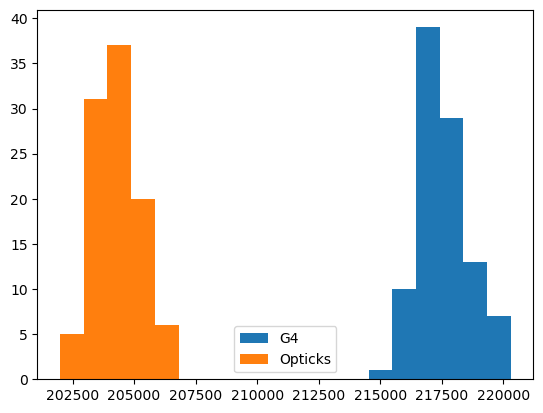

In [272]:
Binsize=20
bnd=[31,30]
maXX=np.max(np.array([np.max(Results["Hits"][b'PMTWindow']),np.max(Results["Hits"][bnd[0]])]))
miNX=np.min(np.array([np.min(Results["Hits"][b'PMTWindow']),np.min(Results["Hits"][bnd[0]])]))
lins1X=np.linspace(miNX,maXX,Binsize)

h1=plt.hist(Results["Hits"][b'PMTWindow'],bins=lins1X,label="G4")
h2=plt.hist(Results["Hits"][bnd[0]],bins=lins1X,label="Opticks")
plt.legend()

In [273]:
MeanG4=np.mean(Results["Hits"][b'PMTWindow'])
MeanOpticks=np.mean(Results["Hits"][bnd[0]])
print(MeanG4-MeanOpticks)

13282.979797979788


In [274]:
print(f"Opticks's mean hit {np.mean(h1[1])}")
print(f"G4's mean hit {np.mean(h2[1])xsim/blob/Diffusion_Opticks/CRAB/src/geometry/OpticalMaterialProperties.cc}")

Opticks's mean hit 211148.5
G4's mean hit 211148.5


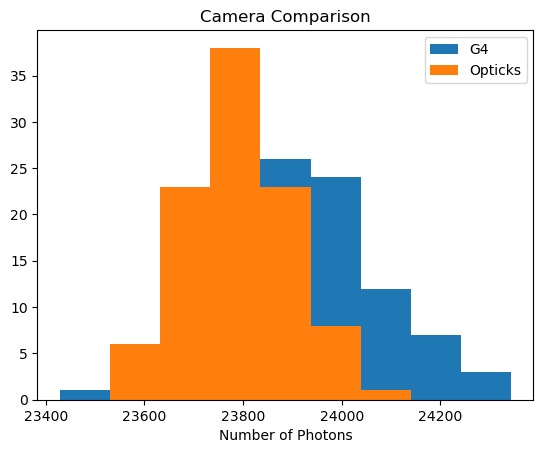

In [279]:
Binsize=10
plt.title("Camera Comparison")
maXX=np.max(np.array([np.max(Results["Hits"][b'camWindow']),np.max(Results["Hits"][bnd[1]])]))
miNX=np.min(np.array([np.min(Results["Hits"][b'camWindow']),np.min(Results["Hits"][bnd[1]])]))
lins1X=np.linspace(miNX,maXX,Binsize)
plt.hist(Results["Hits"][b'camWindow'],bins=lins1X,label="G4")
plt.hist(Results["Hits"][bnd[1]],bins=lins1X,label="Opticks")
plt.xlabel("Number of Photons")
plt.legend()

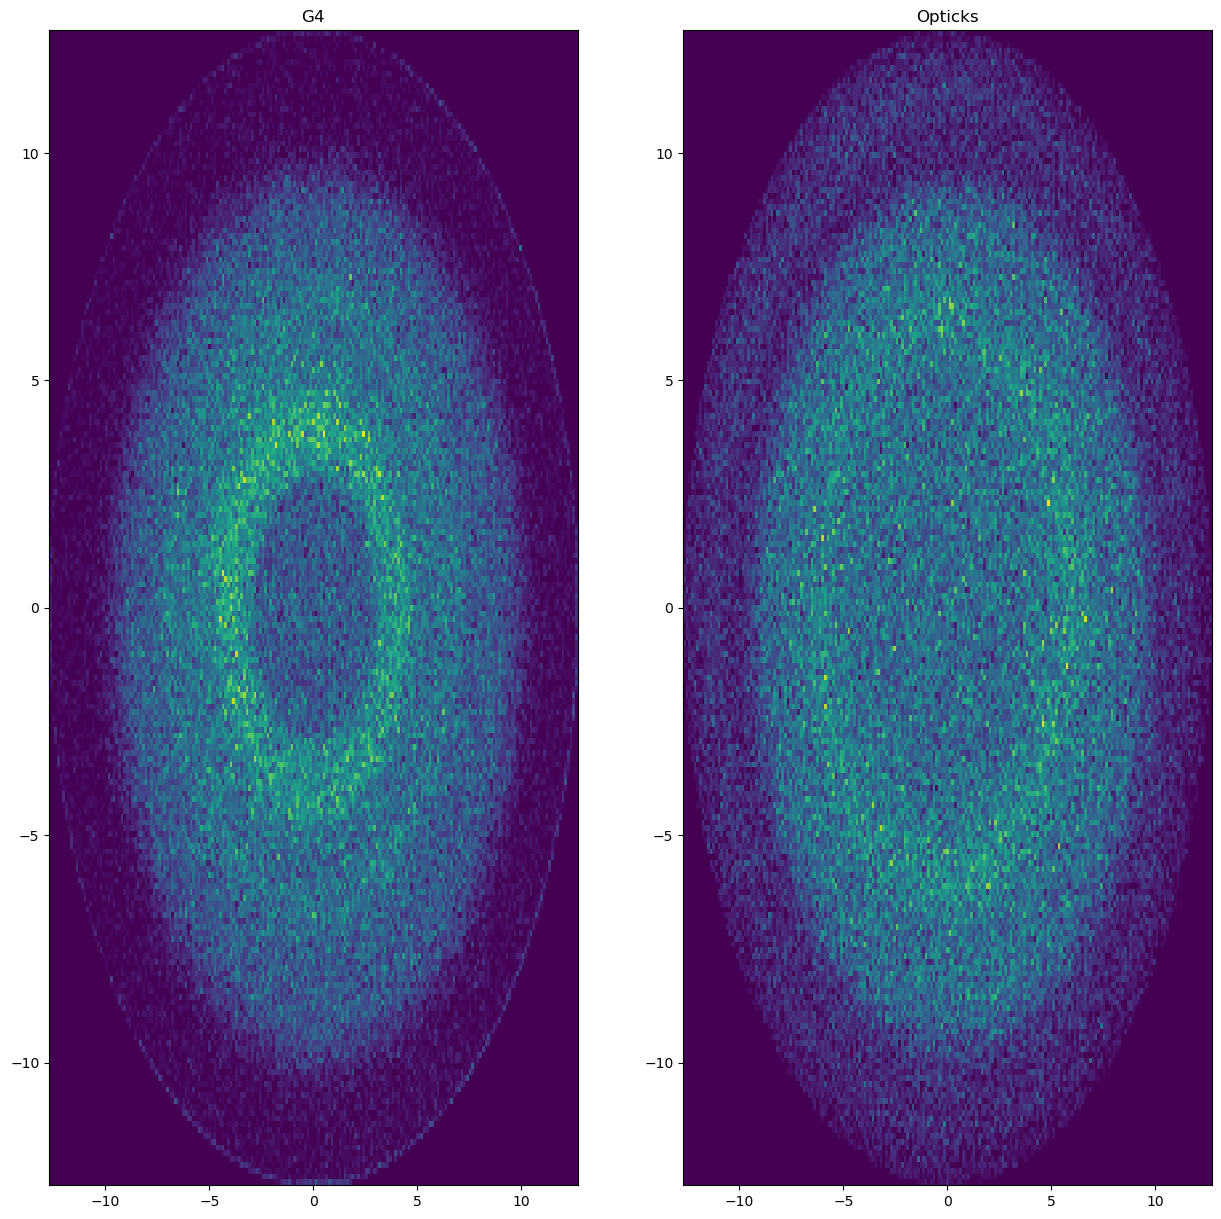

In [276]:

fig,ax=plt.subplots(1,2)
fig.set_figheight(15)
fig.set_figwidth(15)
Binsize=200

maXX=np.max(np.array([np.max(G4X),np.max(OX)]))
miNX=np.min(np.array([np.min(G4X),np.min(OX)]))
lins1X=np.linspace(miNX,maXX,Binsize)

maXY=np.max(np.array([np.max(G4Y),np.max(OY)]))
miNY=np.min(np.array([np.min(G4Y),np.min(OY)]))
lins1Y=np.linspace(miNY,maXY,Binsize)
ax[0].set_title("G4")
ax[0].hist2d(G4X,G4Y,bins=[lins1X,lins1Y],label="G4")
ax[1].set_title("Opticks")
ax[1].hist2d(OX,OY,bins=[lins1X,lins1Y],label="Opticks")

plt.show()


In [ ]:
### Other Performance Results
Laptop_G4=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_G4_100.h5")
Laptop_Opticks=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_Opticks.h5")

ArgonTrx_G4=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_G4_500.h5")
ArgonTrx_Opticks=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_Opticks.h5")

In [ ]:
#run1=GetInfo("/home/argon/Projects/Ilker/NewNexus/run1_Opticks.next.h5")
#OpticksTimeRunPath="/home/argon/Projects/Ilker/NewNexus/TimeRuns/Opticks"
OpticksTimeRunPath="/home/argon/Downloads/Performance/CPB_rtx4090/runtime_Opticks.h5"
run1=GetInfo(OpticksTimeRunPath)

#run2=GetInfo(OpticksTimeRunPath+"/run2.h5")
#run3=GetInfo(OpticksTimeRunPath+"/run3.h5")



In [ ]:
G4TimeRunPath="/home/argon/Projects/Ilker/NewNexus/TimeRuns/G4/run1.h5"
run1G4=GetInfo(G4TimeRunPath)
#run2G4=GetInfo(G4TimeRunPath+"/run2.h5")
#run3G4=GetInfo(G4TimeRunPath+"/run3.h5")

In [ ]:

def EventSummary(key,Event,data,isPrint=True,boundaries=[30,33]):
    if(Event==-1):
        EventLength=len(data["Timing/photons"])
        PMTHits_=np.array([])
        CameraHits_=np.array([])
        for evt in range(0,EventLength):
            EventHitMask=data[f"{key}/event_id"]==evt
            #PhotonCountEventMask=data["Timing/event_id"]==evt
            #TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
            #ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]

            if(key=="Opticks_Hits"):
                tool="Opticks"
                CamHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[0]
                PMTHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[1]
                CameraHits=len(data[f"{key}/boundary"][EventHitMask][CamHitMask])
                PMTHits=len(data[f"{key}/boundary"][EventHitMask][PMTHitMask])
            else:
                tool="G4"
                CamHitMask=data[f"{key}/name"][EventHitMask]==b'camWindow'
                PMTHitMask=data[f"{key}/name"][EventHitMask]==b'PHOTOCATHODE'
                CameraHits=len(data[f"{key}/name"][EventHitMask][CamHitMask])
                PMTHits=len(data[f"{key}/name"][EventHitMask][PMTHitMask])
            PMTHits_=np.append(PMTHits_,PMTHits)
            CameraHits_=np.append(CameraHits_,CameraHits)
        return PMTHits_,CameraHits_     
    
    else:
        EventHitMask=data[f"{key}/event_id"]==Event
        PhotonCountEventMask=data["Timing/event_id"]==Event
        TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
        ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]

        if(key=="Opticks_Hits"):
            tool="Opticks"
            CamHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[0]
            PMTHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[1]
            CameraHits=len(data[f"{key}/boundary"][EventHitMask][CamHitMask])
            PMTHits=len(data[f"{key}/boundary"][EventHitMask][PMTHitMask])
            PMTX=data[f"{key}/x"][EventHitMask][PMTHitMask]
            PMTY=data[f"{key}/y"][EventHitMask][PMTHitMask]
            PMTZ=data[f"{key}/z"][EventHitMask][PMTHitMask]
            CamX=data[f"{key}/x"][EventHitMask][CamHitMask]
            CamY=data[f"{key}/y"][EventHitMask][CamHitMask]
            CamZ=data[f"{key}/z"][EventHitMask][CamHitMask]
        else:
            tool="G4"
            CamHitMask=data[f"{key}/name"][EventHitMask]==b'camWindow'
            PMTHitMask=data[f"{key}/name"][EventHitMask]==b'PHOTOCATHODE'
            CameraHits=len(data[f"{key}/name"][EventHitMask][CamHitMask])
            PMTHits=len(data[f"{key}/name"][EventHitMask][PMTHitMask])
            PMTX=data[f"{key}/x"][EventHitMask][PMTHitMask]
            PMTY=data[f"{key}/y"][EventHitMask][PMTHitMask]
            PMTZ=data[f"{key}/z"][EventHitMask][PMTHitMask]
            CamX=data[f"{key}/x"][EventHitMask][CamHitMask]
            CamY=data[f"{key}/y"][EventHitMask][CamHitMask]
            CamZ=data[f"{key}/z"][EventHitMask][CamHitMask]
        
        if(isPrint):    
            print(f"------------------------ Event {Event} ({tool})------------------------")
            print(f"CameraHits  :  {CameraHits}       , PMTHits {PMTHits}")
            print(f"------------------------------------------------")
            print(f"TotalPhoton :  {TotalPhoton}   , Executation Time {ExecutionTime}")
        return np.array([TotalPhoton,ExecutionTime,PMTHits,CameraHits]),[PMTX,PMTY,PMTZ],[CamX,CamY,CamZ]     
def GetDistributions(runs,key,bnd=[30,33]):
    Values={}
    Values["Photon"]=np.array([])
    Values["ExecutionTime"]=np.array([])
    Values["PMTHits"]=np.array([])
    Values["CameraHits"]=np.array([])

    for run in runs:
        ## Combine All the Photons and times
        Values["Photon"]=np.hstack((Values["Photon"],run['Timing/photons']))
        Values["ExecutionTime"]=np.hstack((Values["ExecutionTime"],run['Timing/time']))
        Results=EventSummary(key,-1,run,isPrint=True,boundaries=bnd)
        Values["PMTHits"]=np.hstack((Values["PMTHits"],Results[0]))
        Values["CameraHits"]=np.hstack((Values["CameraHits"],Results[1]))
        
    return Values    

In [ ]:
print(len(run1["Timing/photons"]))

In [ ]:
np.min(Laptop_Opticks["Timing/photons"]/1e6)

In [ ]:
plt.figure(figsize=(12,8),dpi=300)
plt.plot(np.sort(run1["Timing/photons"]/1e6),np.sort(run1["Timing/time"]),label="Opticks (RTX-4090,VRAM (24GB))",marker="o",markersize=5,color="red")
plt.plot(np.sort(run1G4["Timing/photons"]/1e6),np.sort(run1G4["Timing/time"]),label="G4 (I9-13900k)",marker="*",markersize=5,color="red")
plt.plot(np.sort(Laptop_G4["Timing/photons"]/1e6),np.sort(Laptop_G4["Timing/time"]),label="G4 (i7-11800H )",marker="*",markersize=5,color="blue")
plt.plot(np.sort(Laptop_Opticks["Timing/photons"]/1e6),np.sort(Laptop_Opticks["Timing/time"]),label="Opticks (RTX-3050 Ti (4GB))",marker="o",markersize=5,color="blue")

plt.plot(np.sort(ArgonTrx_G4["Timing/photons"]/1e6),np.sort(ArgonTrx_G4["Timing/time"]),label="G4 (AMD-TRX40)",marker="*",markersize=5,color="green")
plt.plot(np.sort(ArgonTrx_Opticks["Timing/photons"]/1e6),np.sort(ArgonTrx_Opticks["Timing/time"]),label="Opticks (RTX-2060,VRAM (6GB))",marker="o",markersize=5,color="green")

plt.title("Performance")
plt.xlabel("Million Photons")
plt.ylabel("Computation Time (s)")
#plt.axvline(14,0,1000,color="blue")
plt.legend()
plt.semilogy()
plt.show()


In [ ]:
print(f' Max Photon {np.max(np.sort(run1["Timing/photons"]/1e6))}  and Min Photon {np.min(np.sort(run1["Timing/photons"]/1e6))}')
print(f' Max Time {np.max(np.sort(run1["Timing/time"]))}  and Min Time {np.min(np.sort(run1["Timing/time"]))}')

print("-----------------------------------------")
print(f'(G4) Max Photon {np.max(np.sort(run1G4["Timing/photons"]/1e6))}  and Min Photon {np.min(np.sort(run1G4["Timing/photons"]/1e6))}')
print(f'(G4) Max Time {np.max(np.sort(run1G4["Timing/time"]))}  and Min Time {np.min(np.sort(run1G4["Timing/time"]))}')

In [ ]:
Test1=EventSummary("Opticks_Hits",2,run1)
Test1_G4=EventSummary("GEANT4_Optical_Hits",2,run1G4)


f, (ax1, ax2) = plt.subplots(1, 2, sharey=False)
_=ax1.hist2d(Test1[1][1],Test1[1][2],bins=100)
_=ax2.hist2d(Test1_G4[1][1],Test1_G4[1][2],bins=100)

In [ ]:
mask=np.max(run1G4["Timing/photons"])==run1G4["Timing/photons"]
AvgPhot=np.average([run1G4["Timing/photons"],run2G4["Timing/photons"],run3G4["Timing/photons"]])
AvgTime=np.average([run1G4["Timing/time"],run2G4["Timing/time"],run3G4["Timing/time"]])
print(f" Average Photons {AvgPhot} Time {AvgTime}")
AvgPhot=np.average([run1["Timing/photons"],run2["Timing/photons"],run3["Timing/photons"]])
AvgTime=np.average([run1["Timing/time"],run2["Timing/time"],run3["Timing/time"]])
print(f" Average Photons {AvgPhot} Time {AvgTime}")


In [ ]:
### This is reading .txt files
def PerformanceInfo(Path):
    with open(Path,"r") as f:
        lines=f.readlines()
        
    Time=np.array([])
    Photons=np.array([])
    for line in lines:
    
        splited=line.split(",")
        if(splited[0]=="EventID"):
            continue
        Time=np.append(Time,float(splited[1].strip()))
        Photons=np.append(Photons,int(splited[2].strip()))
    return Time,Photons    

In [ ]:
G4Hit=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/G4/GEANT4HitComparison/CRAB/jobid_1/runhit.h5")

In [ ]:
print(G4Hit)

In [ ]:
### HIT Study

run1HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run1.h5")
#run2HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run2.h5")
#run3HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run3.h5")
#run1HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run1.h5")



In [ ]:
import numpy as np


Opticks=EventSummary("Opticks_Hits",2,run1HitOpticks)
G4=EventSummary("GEANT4_Optical_Hits",2,G4Hit)

AveragedOpticks={"PMTX":np.array([]),"PMTY":np.array([]),"CamX":np.array([]),"CamY":np.array([])}
AveragedG4={"PMTX":np.array([]),"PMTY":np.array([]),"CamX":np.array([]),"CamY":np.array([])}
for i in range(0,10):
    Opticks=EventSummary("Opticks_Hits",i,run1HitOpticks)
    G4=EventSummary("GEANT4_Optical_Hits",i,G4Hit)
    AveragedOpticks["PMTX"]=np.append(AveragedOpticks["PMTX"],Opticks[1][0])
    AveragedOpticks["PMTY"]=np.append(AveragedOpticks["PMTY"],Opticks[1][1])
    AveragedOpticks["CamX"]=np.append(AveragedOpticks["CamX"],Opticks[2][0])
    AveragedOpticks["CamY"]=np.append(AveragedOpticks["CamY"],Opticks[2][1])
    AveragedG4["PMTX"]=np.append(AveragedG4["PMTX"],G4[1][0])
    AveragedG4["PMTY"]=np.append(AveragedG4["PMTY"],G4[1][1])
    AveragedG4["CamX"]=np.append(AveragedG4["CamX"],G4[2][0])
    AveragedG4["CamY"]=np.append(AveragedG4["CamY"],G4[2][1])

    


In [ ]:
f,ax = plt.subplots(2, 2, sharey=True,figsize=(15,15))

binns=[np.linspace(-11,11,100),np.linspace(-11,11,100)]
_=ax[0,0].hist2d(AveragedOpticks["PMTX"], AveragedOpticks["PMTY"],bins=binns ,label="Opticks",density=True)
ax[0,0].set_title("Anode Window (Opticks)")
ax[0,0].set_ylabel("(mm)")

ax[0,1].set_title("Anode Window (G4)")
_=ax[0,1].hist2d(AveragedG4["PMTX"], AveragedG4["PMTY"],bins=binns,label="G4")
ax[1,0].set_ylabel("(mm)")

ax[1,0].set_title("Cathode Window (Opticks)")
ax[1,1].set_title("Cathode Window (G4)")
_=ax[1,0].hist2d(AveragedOpticks["CamX"],AveragedOpticks["CamY"],bins=binns ,label="Opticks")

_=ax[1,1].hist2d(AveragedG4["CamX"], AveragedG4["CamY"],bins=binns,label="G4")
plt.subplots_adjust(wspace=0, hspace=0.1)

In [ ]:
G4HitRun=[G4Hit]

In [ ]:
EventSummary("Opticks_Hits",7,run1HitOpticks,True)


In [ ]:
#test=GetInfo("/home/argon/Projects/Ilker/NewNexus/TimeRuns/Opticks/run1.h5")

In [ ]:
OpticksRun=GetDistributions([run1HitOpticks],"Opticks_Hits") #,run2HitOpticks,run3HitOpticks],"Opticks_Hits")
#TestRun=GetDistributions([test],"GEANT4_Optical_Hits")
#TestRun=GetDistributions([test],"Opticks_Hits",bnd=[30,33])

In [ ]:
G4Hits=GetDistributions(G4HitRun,"GEANT4_Optical_Hits")

In [ ]:
print(G4Hits)

In [ ]:
#EventSummary("GEANT4_Optical_Hits",0,test)
EventSummary("Opticks_Hits",8,run1HitOpticks,boundaries=[30,33])

In [ ]:
Test1=EventSummary("Opticks_Hits",2,run1HitOpticks)
Test1_G4=EventSummary("GEANT4_Optical_Hits",5,G4HitRun[21])

f, (ax1, ax2) = plt.subplots(1, 2, sharey=False)
_=ax1.hist2d(Test1[2][0],Test1[2][1],bins=100)
_=ax2.hist2d(Test1_G4[2][0],Test1_G4[2][1],bins=100)

In [ ]:
import scipy.special as misc
from scipy.special import loggamma

def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)

In [ ]:
plt.hist(G4Hits["Photon"],label="G4")
plt.hist(OpticksRun["Photon"],label="Opticks")
plt.legend()

In [ ]:
#plt.hist(G4Hits["ExecutionTime"])
plt.hist(G4Hits["ExecutionTime"][G4Hits["ExecutionTime"]<600])


In [ ]:
print(np.mean(OpticksRun["ExecutionTime"]))
print (np.mean((G4Hits["ExecutionTime"][G4Hits["ExecutionTime"]<600])))

In [ ]:
Mask=G4Hits["ExecutionTime"]<500


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=G4Hits["PMTHits"][Mask]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=20,label="G4 Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=G4Hits["CameraHits"][Mask]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=15,label="G4 Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=OpticksRun["PMTHits"]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=30,label="Opticks Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Cathode PMT Hits")
CorrectedHits=OpticksRun["CameraHits"]*(0.84)*(0.86)*0.097 #/5.3
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=30,color="red",label="Opticks Hits")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
print(f"{fit[0][1]}")
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red")
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [1]:
%reset -f